#### To Do:

- fix with Amelie that the names are the same of all the files: easier! 
- How to control for noise ==> curve_4 => noise after sec 6 (i think) -> how to fix it?
- link segment time with angle time !! -> fix data qtm: naming + conversion to opensim: GRF included: easier to calculate contact time

In [1]:
# load the project root into the notebook to be able to load functions from other modules
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "tests":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 
from Base.Opensim_analysis_code import angle_plot, analyze_folder_OS, merge_left_contacts
from Base.GRF_analysis_code import analyze_folder_segm

print(os.getcwd())

/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests
/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests
/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests


In [3]:
folder = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "files")
df_segm = analyze_folder_segm(folder)



In [4]:
OS = analyze_folder_OS("../../files/OpenSim")
left_contacts = df_segm[df_segm["plate"] == "FP1"].copy()
left_contacts["participant"] = left_contacts["participant"].replace({
    "01": "ED",
    "02": "MN"
})

left_contacts["condition"] = left_contacts["condition"].str.capitalize()
left_contacts["trial"] = left_contacts["trial"].astype(str)
left_contacts["shoe"] = left_contacts["shoe"].astype(str)

OS_stance_left = {}
for key in OS:
    if key.endswith("_r"):
        continue

    angle_df = OS[key].copy()
    angle_df_stance = merge_left_contacts(angle_df, left_contacts)
    OS_stance_left[key] = angle_df_stance



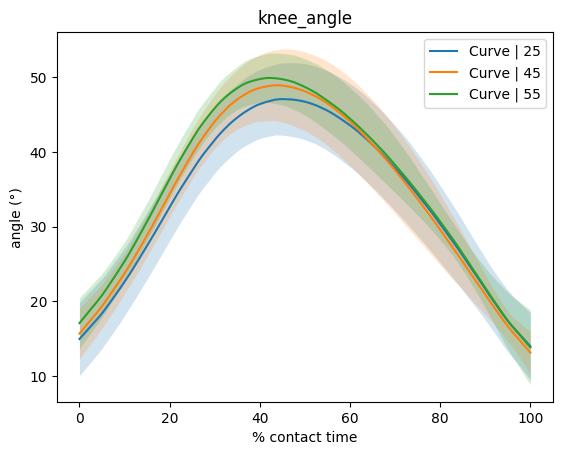

In [7]:
angle_plot(OS_stance_left, joint= "knee_angle", comparison= ["condition", "shoe"], condition="Curve", side="l")